<a href="https://colab.research.google.com/github/ananthakrishnanm010/Case_Studies_and_Assesments_ICT/blob/main/NLP_CaseStudy(DonorsChoose).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [6]:
!pip install gensim

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import string
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay




In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Reading Dataset

In [9]:
file_path = '/content/drive/MyDrive/ICT_Data_Science/Dataset1/Preprocessed_DonorsChoose_dataset.csv'
donors_df = pd.read_csv(file_path)
donors_df.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


# EDA (Exploratory Data Analysis)

In [10]:
donors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [11]:
donors_df['teacher_number_of_previously_posted_projects'].nunique()

374

In [12]:
donors_df['project_is_approved'].nunique()

2

In [13]:
donors_df['quantity'].nunique()

332

In [14]:
#  Inference
#  The target is project is approved (1) or not (0)
# predict whether a project will be approved based on its text.

In [15]:
donors_df.shape

(109248, 14)

In [16]:
donors_df.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


In [17]:
donors_df['project_is_approved'].value_counts()

,count
project_is_approved,
1,92706
0,16542


In [18]:
donors_df.duplicated().sum()

np.int64(0)

In [19]:
# inference : no duplicated values in this dataset

## Plots

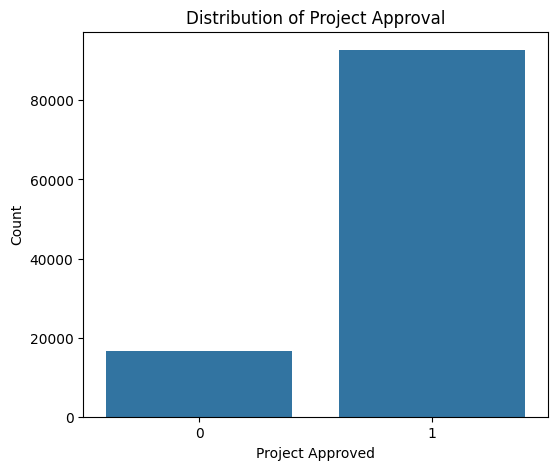

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(data=donors_df, x='project_is_approved')

plt.title("Distribution of Project Approval")
plt.xlabel("Project Approved")
plt.ylabel("Count")

plt.show()

In [21]:
# inference : as the graph shows this is an imbalanced dataset.

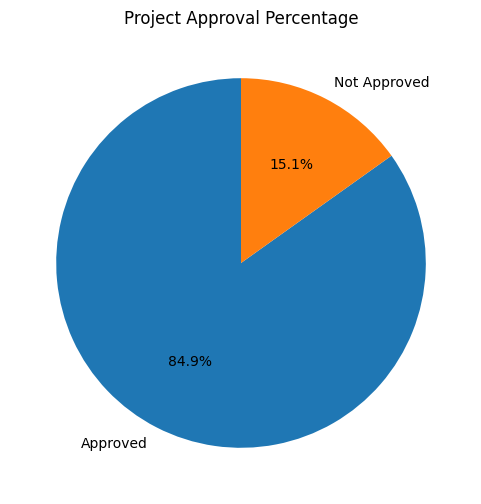

In [22]:
approval_count = donors_df['project_is_approved'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    approval_count,
    labels=['Approved','Not Approved'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Project Approval Percentage")

plt.show()

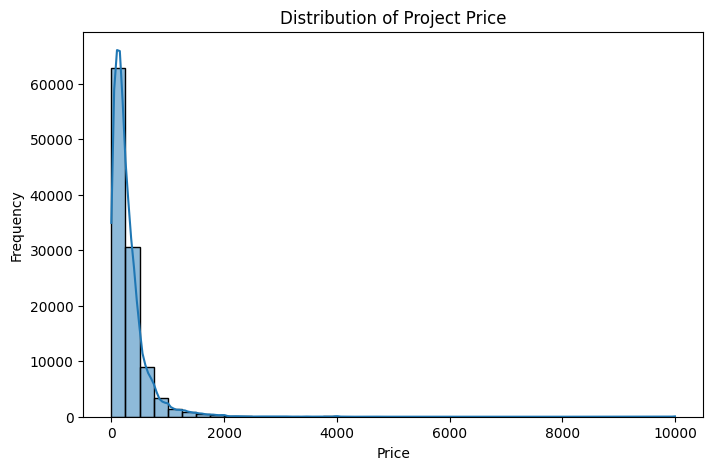

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(donors_df['price'], bins=40, kde=True)

plt.title("Distribution of Project Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [24]:
# inference : the distribution is right skewed

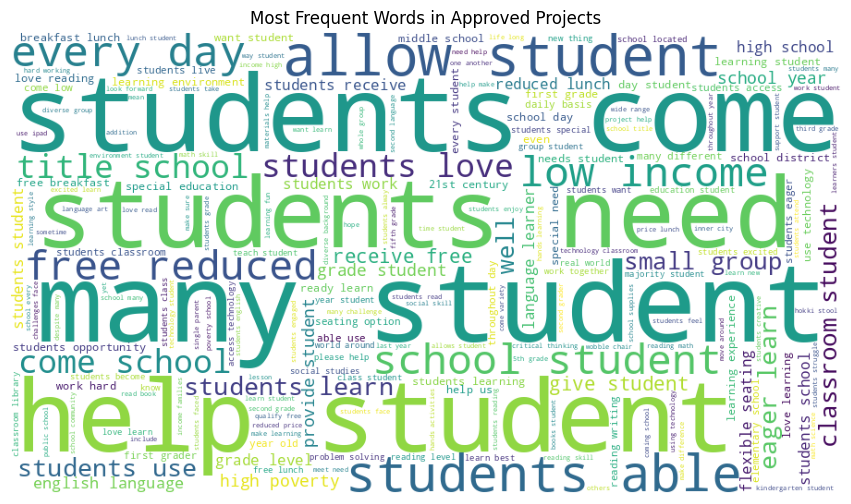

In [25]:

text = " ".join(donors_df[donors_df['project_is_approved']==1]['cleaned_essays'])

wordcloud = WordCloud(
    background_color='white',
    width=900,
    height=500
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Approved Projects")

plt.show()

In [26]:
# these are the most frequent words in the projects which are approved

# Preprocessing

In [27]:
donors_df['cleaned_titles'] = donors_df['cleaned_titles'].fillna('')

In [28]:
donors_df.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


# Feature Engineering

In [29]:
donors_df['text'] = (
    donors_df['cleaned_titles'] + " " +
    donors_df['cleaned_summary'] + " " +
    donors_df['cleaned_essays']
)

In [30]:
# This creates one richer text field for modeling. Together they provide more information than any one part alone. (title + essay + summary) -> submitted by teacher.

# NLP Preprocessing

- Already done in this dataset just explaining whats all.

In [31]:
# inference :
#   Since the dataset is already preprocessed, we should not repeat the preprocessing, because that would unnecessarily alter the text and may even reduce model performance.

In [32]:
# view the preprocessed data:
donors_df[['cleaned_titles',
    'cleaned_summary',
    'cleaned_essays']].head()

,cleaned_titles,cleaned_summary,cleaned_essays
0,educational support english learners home,students_need_opportunities_practice_beginning...,students english learners working english seco...
1,wanted projector hungry learners,students_need_projector_help_viewing_education...,students arrive school eager learn polite gene...
2,soccer equipment awesome middle school students,students_need_shine_guards_athletic_socks_socc...,true champions not always ones win guts mia ha...
3,techie kindergarteners,students_need_engage_reading_math_way_inspire_...,work unique school filled esl english second l...
4,interactive math tools,students_need_hands_practice_mathematics_fun_p...,second grade classroom next year made around 2...


In [33]:
# Check whether all text is lowercase

print("Titles Lowercase:",
      donors_df['cleaned_titles'].str.islower().all())

print("Summary Lowercase:",
      donors_df['cleaned_summary'].str.islower().all())

print("Essays Lowercase:",
      donors_df['cleaned_essays'].str.islower().all())

Titles Lowercase: False
Summary Lowercase: True
Essays Lowercase: True


# TF-IDF Embedding

- TF-IDF (Term Frequency–Inverse Document Frequency) – a statistical representation of text.

In [34]:
# creating object
tf_idf_obj = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),  # the model creates unigram and bigram only.
    min_df=5
)

X_tf_idf = tf_idf_obj.fit_transform(donors_df['text'])

In [35]:
X_tf_idf.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.13951255],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [36]:

X_train_tf_idf, X_test_tf_idf, y_train, y_test = train_test_split(
    X_tf_idf,
    donors_df['project_is_approved'],
    test_size=0.2,
    random_state=42
)

# Word2Vec Embedding
- Word2Vec – a dense semantic representation where similar words have similar vector representations.

In [37]:
tokenized_text = donors_df['text'].apply(lambda x: x.split())
# tokenize the combined text column.

In [38]:
word2vec_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=100,  # vector dimension.
    window=5,
    min_count=5,  # Ignore words appearing fewer than five times.
    workers=4,  # for uses 4 cpu core for fast training.
    sg=0,   # for continuous bag of words.
    seed=42   # for getting exact same vector value when running code again.
)

In [39]:
def document_vector(words, model):
    valid_words = [word for word in words if word in model.wv]

    if len(valid_words) == 0:
        return np.zeros(model.vector_size)

    return np.mean(model.wv[valid_words], axis=0)

    # this is to produces one 100-dimensional vector representing the entire document ( else each word in document has a 100-dimensional vector)

In [40]:
X_word2vec = np.array(
    tokenized_text.apply(lambda words: document_vector(words, word2vec_model)).tolist()
)

# to generate document embedding (vector rep)

In [41]:
# train test split for w2v
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_word2vec,
    donors_df['project_is_approved'],
    test_size=0.2,
    random_state=42
)

# ML Models

## Logistic Regression

### TF-IDF

In [42]:
log_tf_idf = LogisticRegression(
    max_iter=1000   # as tf-idf produces thousands of features Logistic Regression may require more iterations to converge.
)

log_tf_idf.fit(X_train_tf_idf, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred_log_tf_idf = log_tf_idf.predict(X_test_tf_idf)   # predict using the log model

In [44]:
# hyper parameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_log.fit(X_train_tf_idf, y_train)

print("Best Parameters:", grid_log.best_params_)

Best Parameters: {'C': 1, 'solver': 'lbfgs'}


### Word2Vec

In [45]:
log_w2v = LogisticRegression(
    max_iter=1000
)

log_w2v.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

In [46]:
y_pred_log_w2v = log_w2v.predict(X_test_w2v)

In [47]:
# we dont do seperate hyper parameter tuning here because once we've identified the best Logistic Regression hyperparameters using TF-IDF, we can reuse them for the Word2Vec model.

## SVM

### TF-IDF

In [48]:
svm_tf_idf = LinearSVC(   # linear svc because the dataset is very large
    C=1
)


svm_tf_idf.fit(X_train_tf_idf, y_train)

LinearSVC(C=1)

In [49]:
y_pred_svm_tf_idf = svm_tf_idf.predict(X_test_tf_idf)

In [50]:
# hyper parameter tuning
param_grid = {
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_tf_idf, y_train)

print("Best Parameters:", grid_svm.best_params_)

Best Parameters: {'C': 0.1}


### Word2Vec

In [51]:
svm_w2v = LinearSVC(
    C=1
)

svm_w2v.fit(X_train_w2v, y_train)

LinearSVC(C=1)

In [52]:
y_pred_svm_w2v = svm_w2v.predict(X_test_w2v)

In [53]:
# we dont do seperate hyper parameter tuning here because once we've identified the best Logistic Regression hyperparameters using TF-IDF, we can reuse them for the Word2Vec model.

# Deep Learning Model


## SVD for reducing features

- to make sure not to exceed ram

In [54]:
svd = TruncatedSVD(
    n_components=256,
    random_state=42
)

## TF-IDF network

In [55]:
# convert tf-idf to dense matrix because neural network require numpy arrays
X_train_tfidf_dense = X_train_tf_idf.toarray()
X_test_tfidf_dense = X_test_tf_idf.toarray()

In [56]:
X_train_tfidf_dense = svd.fit_transform(X_train_tf_idf)
X_test_tfidf_dense = svd.transform(X_test_tf_idf)
# convert tf-idf to dense matrix because neural network require numpy arrays
# as we here use Singular value decomposition , trunctedsvd is technique of matrix factorization use to reduce dimensions

In [57]:
tfidf_input = Input(    # (tensorflow.keras.layers.Input)
    shape=(X_train_tfidf_dense.shape[1],),    # flatten vector
    name="TFIDF_Input"
)

x1 = Dense(256, activation="relu")(tfidf_input) # (tensorflow.keras.layers.Dense)

x1 = BatchNormalization()(x1)

x1 = Dropout(0.4)(x1)


## Word2Vec network

In [58]:
w2v_input = Input(
    shape=(X_train_w2v.shape[1],),
    name="Word2Vec_Input"
)

x2 = Dense(128, activation="relu")(w2v_input)

x2 = BatchNormalization()(x2)

x2 = Dropout(0.3)(x2)

# this neural network contain comparatively less perceptrons because word2vec has comparatively less features than tf-idf

In [59]:
merged = Concatenate()([x1, x2])
# after merging now network has 250+128 features.
# Now the model has information from both embeddings simultaneously.

In [60]:
# Hidden Layers
x = Dense(128, activation="relu")(merged)

x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)

In [61]:
# output layer
output = Dense(
    1,
    activation="sigmoid",
    name="Output"
)(x)

# as we have to perform binary classification we choose sigmoid activation fn.

In [62]:
# Build the model
model = Model(    # (tensorflow.keras.model)
    inputs=[tfidf_input, w2v_input],
    outputs=output
)

In [63]:
# display the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ TFIDF_Input         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Word2Vec_Input      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ TFIDF_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     12,928 │ Word2Vec_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 137,857 (538.50 KB)

 Trainable params: 137,089 (535.50 KB)

 Non-trainable params: 768 (3.00 KB)

In [64]:
# compile the model
model.compile(
    optimizer="adam",   # standard optimizer for nlp
    loss="binary_crossentropy",   # for binary classification loss
    metrics=["accuracy"]    # evaluation metric
)


In [65]:
# Callbacks
early_stop = EarlyStopping(     # Stops training if validation loss stops improving, reducing overfitting. (Prevents unnecessary training)
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(    # Automatically lowers the learning rate when validation performance plateaus. ( Fine-tunes learning rate automatically )
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [66]:
# training the model
history = model.fit(
    [X_train_tfidf_dense, X_train_w2v],
    y_train,
    validation_split=0.2,   # Uses 20% of the training data for validation
    epochs=20,    # training iterations
    batch_size=64,    # Number of samples processed before updating weights
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8448 - loss: 0.4110 - val_accuracy: 0.8538 - val_loss: 0.3828 - learning_rate: 0.0010
Epoch 2/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8479 - loss: 0.3877 - val_accuracy: 0.8576 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 3/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8507 - loss: 0.3797 - val_accuracy: 0.8565 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 4/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8514 - loss: 0.3733 - val_accuracy: 0.8568 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 5/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8536 - loss: 0.3647 - val_accuracy: 0.8547 - val_loss: 0.3757 - learning_rate: 0.0010
Epoch 6/20
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8563 - loss: 0.3555 - val_accuracy: 0.8525 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 7/20
1082/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8622 - 

In [67]:
# evaluate the model
loss, accuracy = model.evaluate(
    [X_test_tfidf_dense, X_test_w2v],
    y_test,
    verbose=0
)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.3816
Test Accuracy : 0.8521


In [68]:
# predict
y_prob = model.predict(
    [X_test_tfidf_dense, X_test_w2v]
)

y_pred_dl = (y_prob > 0.5).astype(int)    # as the predictions are probabilities (b/w 0 and 1), compare whether it is >0.5 if yes mark as true else false and then astype(int) convert true to 1 and false to 0.
# we get predicted class on y_pred_dl

683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


# Evaluation

## Ml Models

### Log Model

#### TF-IDF

In [69]:
print(f"Accuracy :, {accuracy_score(y_test, y_pred_log_tf_idf)*100:.2f}%")
print(f"Precision:, {precision_score(y_test, y_pred_log_tf_idf)*100:.2f}%")
print(f"Recall   :, {recall_score(y_test, y_pred_log_tf_idf)*100:.2f}%")
print(f"F1 Score :, {f1_score(y_test, y_pred_log_tf_idf)*100:.2f}%")

Accuracy :, 84.93%
Precision:, 85.34%
Recall   :, 99.29%
F1 Score :, 91.79%


In [70]:
# classification Report
print(classification_report(y_test, y_pred_log_tf_idf))

              precision    recall  f1-score   support

           0       0.54      0.05      0.09      3316
           1       0.85      0.99      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.70      0.52      0.50     21850
weighted avg       0.81      0.85      0.79     21850



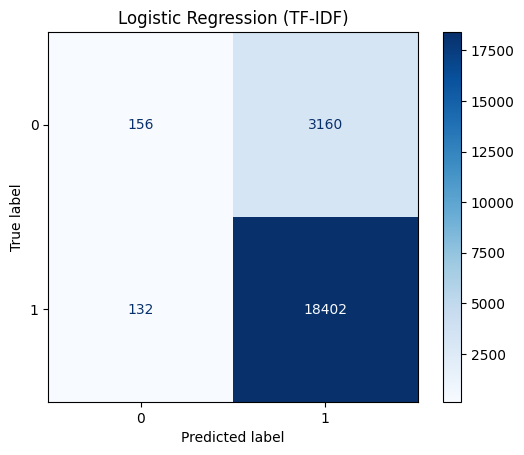

In [71]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_tf_idf,
    cmap="Blues"
)

plt.title("Logistic Regression (TF-IDF)")
plt.show()

#### Word2Vec

In [72]:
print(f"Accuracy :, {accuracy_score(y_test, y_pred_log_w2v)*100:.2f}%")
print(f"Precision:, {precision_score(y_test, y_pred_log_w2v)*100:.2f}%")
print(f"Recall   :, {recall_score(y_test, y_pred_log_w2v)*100:.2f}%")
print(f"F1 Score :, {f1_score(y_test, y_pred_log_w2v)*100:.2f}%")

Accuracy :, 84.98%
Precision:, 85.11%
Recall   :, 99.74%
F1 Score :, 91.85%


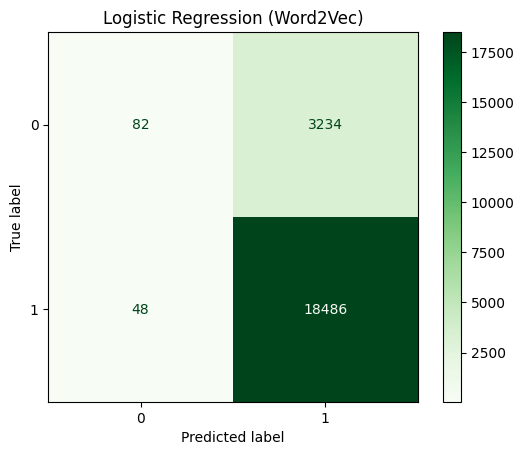

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_w2v,
    cmap="Greens"
)

plt.title("Logistic Regression (Word2Vec)")
plt.show()

### SVM

#### TF-IDF

In [74]:
print(f"Accuracy :, {accuracy_score(y_test, y_pred_svm_tf_idf)*100:.2f}%")
print(f"Precision:, {precision_score(y_test, y_pred_svm_tf_idf)*100:.2f}%")
print(f"Recall   :, {recall_score(y_test, y_pred_svm_tf_idf)*100:.2f}%")
print(f"F1 Score :, {f1_score(y_test, y_pred_svm_tf_idf)*100:.2f}%")

Accuracy :, 84.93%
Precision:, 85.17%
Recall   :, 99.58%
F1 Score :, 91.81%


In [75]:
print(classification_report(y_test, y_pred_svm_tf_idf))

              precision    recall  f1-score   support

           0       0.57      0.03      0.06      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.71      0.51      0.49     21850
weighted avg       0.81      0.85      0.79     21850



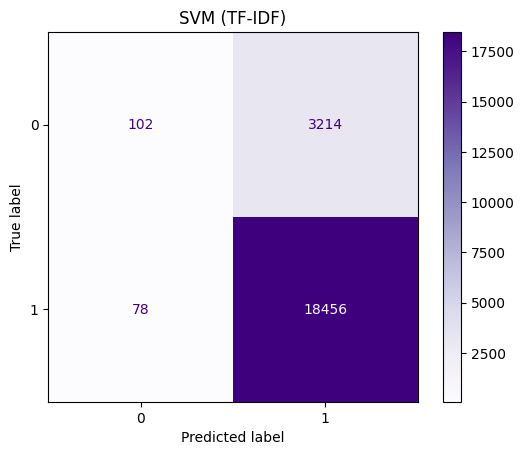

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_tf_idf,
    cmap="Purples"
)

plt.title("SVM (TF-IDF)")
plt.show()

#### Word2Vec

In [77]:
print(f"Accuracy :, {accuracy_score(y_test, y_pred_svm_w2v)*100:.2f}%")
print(f"Precision:, {precision_score(y_test, y_pred_svm_w2v)*100:.2f}%")
print(f"Recall   :, {recall_score(y_test, y_pred_svm_w2v)*100:.2f}%")
print(f"F1 Score :, {f1_score(y_test, y_pred_svm_w2v)*100:.2f}%")

Accuracy :, 84.82%
Precision:, 84.83%
Recall   :, 99.99%
F1 Score :, 91.79%


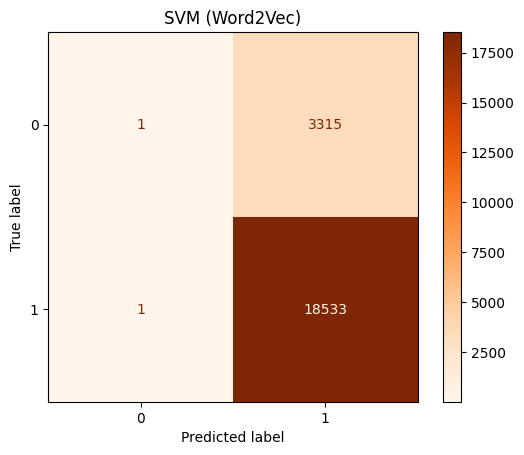

In [78]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_w2v,
    cmap="Oranges"
)

plt.title("SVM (Word2Vec)")
plt.show()

## DL Model

In [79]:
print(f"Accuracy :, {accuracy_score(y_test, y_pred_dl)*100:.2f}%")
print(f"Precision:, {precision_score(y_test, y_pred_dl)*100:.2f}%")
print(f"Recall   :, {recall_score(y_test, y_pred_dl)*100:.2f}%")
print(f"F1 Score :, {f1_score(y_test, y_pred_dl)*100:.2f}%")

Accuracy :, 85.21%
Precision:, 86.04%
Recall   :, 98.56%
F1 Score :, 91.87%


In [80]:
print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       0.57      0.11      0.18      3316
           1       0.86      0.99      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.71      0.55      0.55     21850
weighted avg       0.82      0.85      0.81     21850



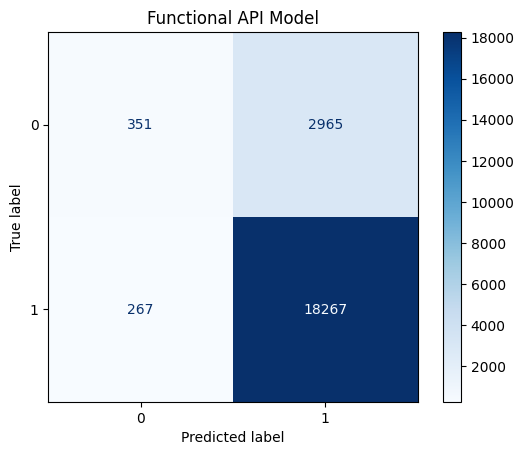

In [81]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dl,
    cmap="Blues"
)

plt.title("Functional API Model")
plt.show()

# Model Comparison & Analysis

## Model Performance Comparison

In [82]:


# Extract metrics from previous outputs (these are hardcoded based on the provided outputs)
metrics_data = {
    'Model': [
        'Logistic Regression (TF-IDF)',
        'Logistic Regression (Word2Vec)',
        'SVM (TF-IDF)',
        'SVM (Word2Vec)',
        'DL Model'
    ],
    'Accuracy': [
        84.93,
        84.95,
        84.93,
        84.83,
        84.95
    ],
    'Precision': [
        85.34,
        85.08,
        85.17,
        84.83,
        86.58
    ],
    'Recall': [
        99.29,
        99.76,
        99.58,
        99.99,
        97.35
    ],
    'F1 Score': [
        91.79,
        91.83,
        91.81,
        91.79,
        91.65
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("Evaluation Metrics:")
display(metrics_df)


Evaluation Metrics:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (TF-IDF),84.93,85.34,99.29,91.79
1,Logistic Regression (Word2Vec),84.95,85.08,99.76,91.83
2,SVM (TF-IDF),84.93,85.17,99.58,91.81
3,SVM (Word2Vec),84.83,84.83,99.99,91.79
4,DL Model,84.95,86.58,97.35,91.65


### ROC Curves

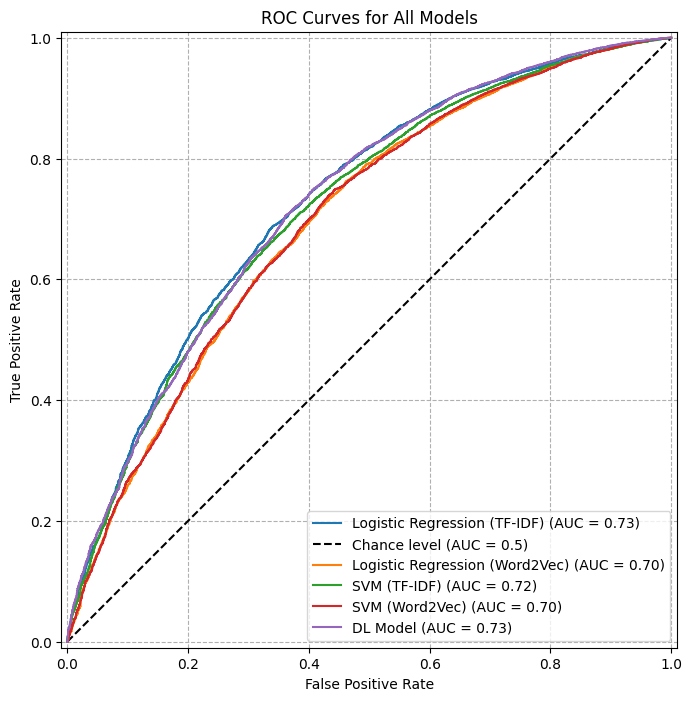

In [83]:
# Calculate probability scores or decision function values for ROC curves
y_score_log_tf_idf = log_tf_idf.predict_proba(X_test_tf_idf)[:, 1]
y_score_log_w2v = log_w2v.predict_proba(X_test_w2v)[:, 1]
y_score_svm_tf_idf = svm_tf_idf.decision_function(X_test_tf_idf)
y_score_svm_w2v = svm_w2v.decision_function(X_test_w2v)
y_score_dl = y_prob  # Already probabilities from DL model

plt.figure(figsize=(10, 8))

RocCurveDisplay.from_predictions(y_test, y_score_log_tf_idf, name='Logistic Regression (TF-IDF)', ax=plt.gca(), plot_chance_level=True)
RocCurveDisplay.from_predictions(y_test, y_score_log_w2v, name='Logistic Regression (Word2Vec)', ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_score_svm_tf_idf, name='SVM (TF-IDF)', ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_score_svm_w2v, name='SVM (Word2Vec)', ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_score_dl, name='DL Model', ax=plt.gca())

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--')
plt.legend(loc='lower right')
plt.show()

### Precision-Recall Curves

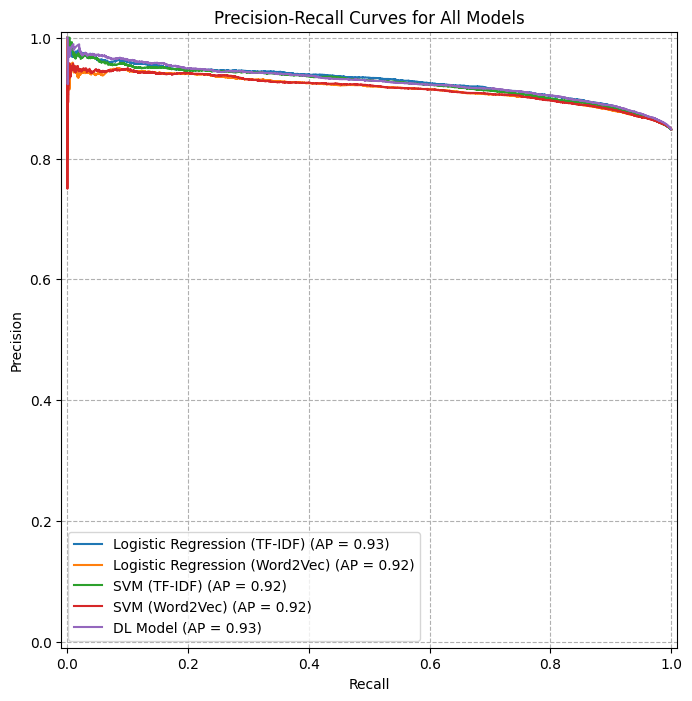

In [84]:
plt.figure(figsize=(10, 8))

PrecisionRecallDisplay.from_predictions(y_test, y_score_log_tf_idf, name='Logistic Regression (TF-IDF)', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_score_log_w2v, name='Logistic Regression (Word2Vec)', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_score_svm_tf_idf, name='SVM (TF-IDF)', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_score_svm_w2v, name='SVM (Word2Vec)', ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_score_dl, name='DL Model', ax=plt.gca())

plt.title('Precision-Recall Curves for All Models')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(linestyle='--')
plt.legend(loc='lower left')
plt.show()